In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [45]:
users = pd.read_csv("train_users.csv")
print(users.shape)
users.head()


(2000, 6)


,user_id,age,income,clicks,purchase_amount,label
0,1,28,58242,81,378.38,user3
1,2,28,38225,21,114.50,user3
2,3,39,95017,41,66.24,user2
3,4,52,33473,98,496.88,user3
4,5,29,80690,5,293.24,user1


In [46]:
num_cols = ["age", "income", "clicks", "purchase_amount"]

for col in num_cols:
    users[col].fillna(users[col].median(), inplace=True)


In [47]:
def engineer_features(df):
    df = df.copy()

    # Interaction features
    df["clicks_per_age"] = df["clicks"] / (df["age"] + 1)
    df["spend_per_click"] = df["purchase_amount"] / (df["clicks"] + 1)
    df["income_per_age"] = df["income"] / (df["age"] + 1)

    # Log transforms
    df["log_income"] = np.log1p(df["income"])
    df["log_clicks"] = np.log1p(df["clicks"])
    df["log_purchase"] = np.log1p(df["purchase_amount"])

    # Age binning
    df["age_bin"] = pd.cut(
        df["age"],
        bins=[0, 25, 35, 45, 60, np.inf],
        labels=[0, 1, 2, 3, 4],
        include_lowest=True
    ).astype(int)

    return df


In [48]:
users = engineer_features(users)


In [49]:
label_encoder = LabelEncoder()
users["label_encoded"] = label_encoder.fit_transform(users["label"])

print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))


{'user1': 0, 'user2': 1, 'user3': 2}


In [50]:
feature_cols = [
    "age", "income", "clicks", "purchase_amount",
    "clicks_per_age", "spend_per_click", "income_per_age",
    "log_income", "log_clicks", "log_purchase",
    "age_bin"
]

X = users[feature_cols]
y = users["label_encoded"]


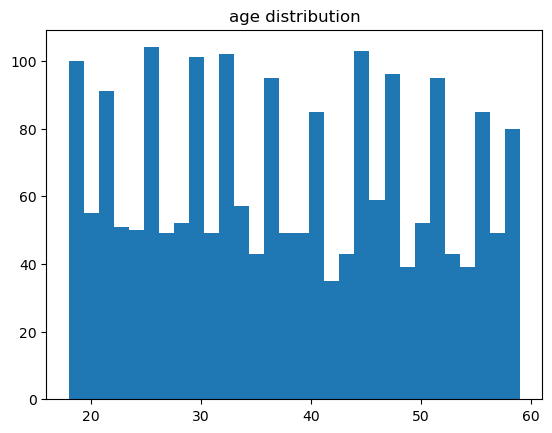

age skew: 0.05499312749193123


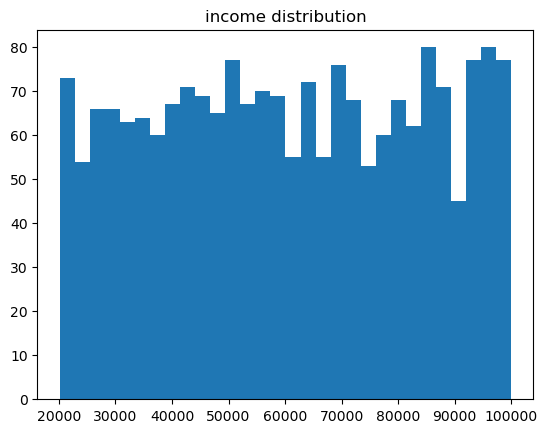

income skew: -0.0005198312440375701


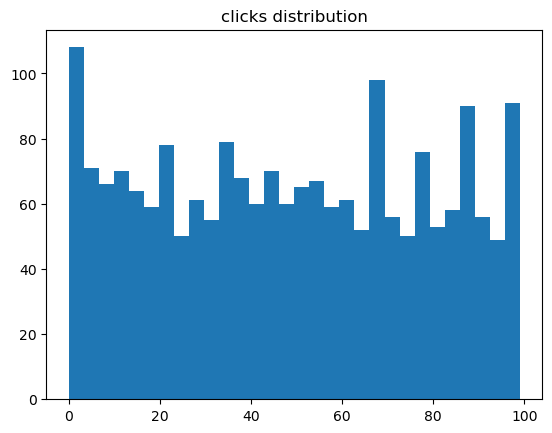

clicks skew: 0.01887427639021527


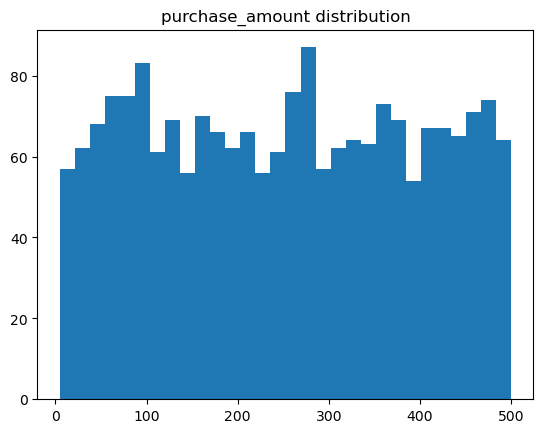

purchase_amount skew: 0.016796345886909335


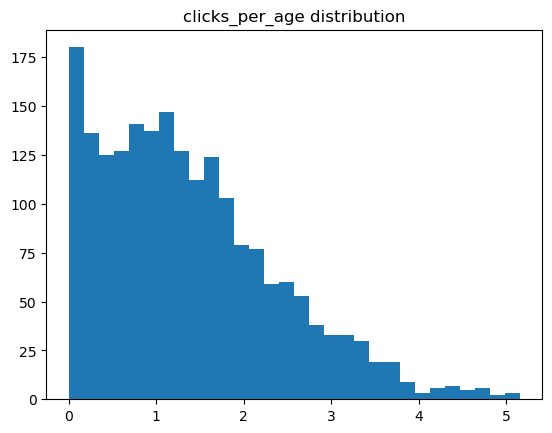

clicks_per_age skew: 0.8362966625735896


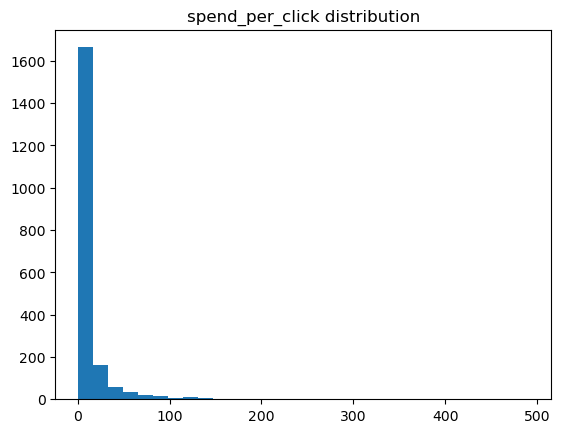

spend_per_click skew: 7.21878812704523


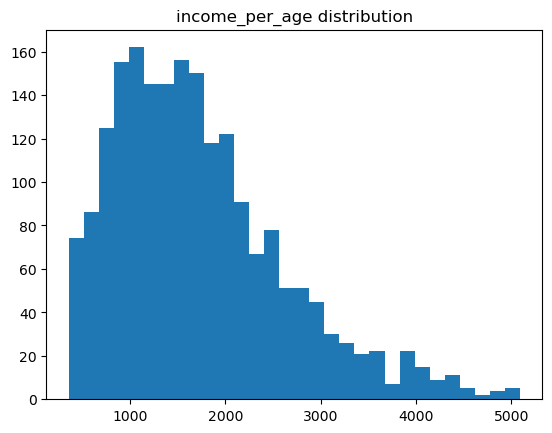

income_per_age skew: 0.9679220752057517


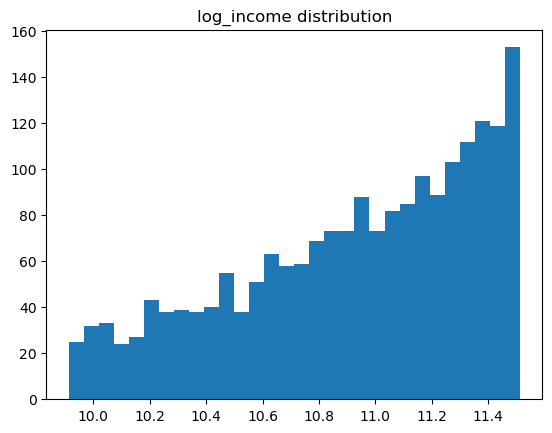

log_income skew: -0.5586837638349931


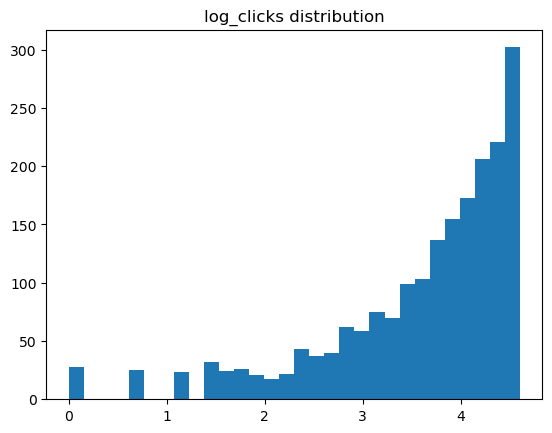

log_clicks skew: -1.4859497472045855


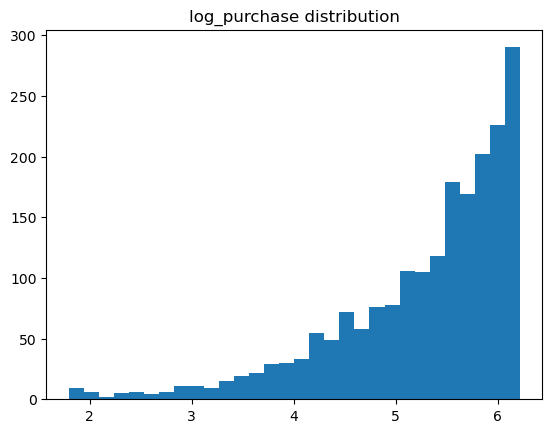

log_purchase skew: -1.3762056600662338


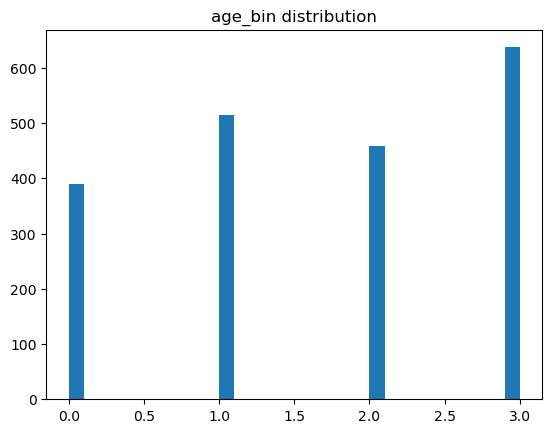

age_bin skew: -0.16772773844213157


In [51]:
for col in feature_cols:
    plt.figure()
    plt.hist(X[col], bins=30)
    plt.title(f"{col} distribution")
    plt.show()
    print(f"{col} skew:", X[col].skew())


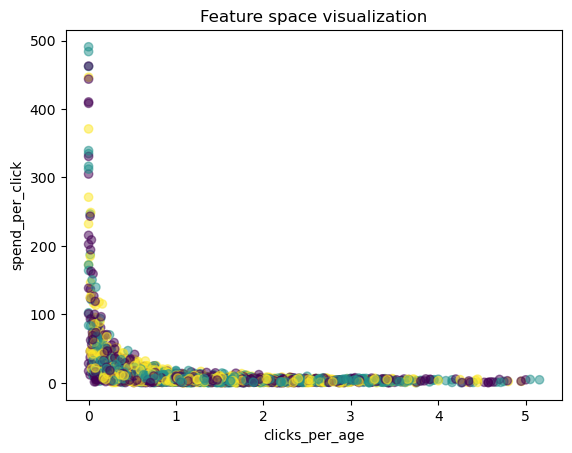

In [52]:
plt.figure()
plt.scatter(
    users["clicks_per_age"],
    users["spend_per_click"],
    c=y,
    alpha=0.5
)
plt.xlabel("clicks_per_age")
plt.ylabel("spend_per_click")
plt.title("Feature space visualization")
plt.show()


In [53]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [54]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    rf_model,
    X_scaled,
    y,
    cv=cv,
    scoring="accuracy"
)

print("CV accuracies:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())


CV accuracies: [0.3525 0.3125 0.365  0.365  0.37  ]
Mean CV accuracy: 0.35300000000000004
Std CV accuracy: 0.021059439688652686


In [55]:
rf_model.fit(X_scaled, y)

y_pred = rf_model.predict(X_scaled)
print(classification_report(y, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       687
           1       1.00      1.00      1.00       669
           2       1.00      1.00      1.00       644

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [56]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance


,feature,importance
6,income_per_age,0.114815
9,log_purchase,0.106314
3,purchase_amount,0.106077
5,spend_per_click,0.105713
4,clicks_per_age,0.105467
1,income,0.104776
7,log_income,0.104353
0,age,0.081121
8,log_clicks,0.076753
2,clicks,0.076409


In [57]:
important_features = feature_importance[
    feature_importance["importance"] > 0.05
]["feature"].tolist()

important_features


['income_per_age',
 'log_purchase',
 'purchase_amount',
 'spend_per_click',
 'clicks_per_age',
 'income',
 'log_income',
 'age',
 'log_clicks',
 'clicks']